In [ ]:
#importina the important modules/libraries for total analysis
import pandas as pd
from operator import mul

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec


import numpy as np+

In [91]:
dim_customers=pd.read_excel("C:/jupyternotebook/Pizza_Company_Final_With_Expense_Category.xlsx",0)
dim_products=pd.read_excel("C:/jupyternotebook/Pizza_Company_Final_With_Expense_Category.xlsx",1)
dim_stores=pd.read_excel("C:/jupyternotebook/Pizza_Company_Final_With_Expense_Category.xlsx",2)
fact_sales=pd.read_excel("C:/jupyternotebook/Pizza_Company_Final_With_Expense_Category.xlsx",3)
dim_expences=pd.read_excel("C:/jupyternotebook/Pizza_Company_Final_With_Expense_Category.xlsx",4)

In [92]:
#A Function which can used to convert the numarical number into formatted numbers 
def smart_format(n):
    if abs(n) >= 1000000000:
        return f"{n / 1_000_000_000:.2f}B"
    elif abs(n) >= 1_000_000:
        return f"{n / 1_000_000:.2f}M"
    elif abs(n) >= 1_000:
        return f"{n / 1_000:.2f}K"
    else:
        return str(n)


Phase one analysis Executive analysis ----->

In [ ]:
#ADD-IN's into the dataframer

#droping a unwanted column from the fact_sales
fact_sales.drop(columns=["Unit_Price","Cost_Price"],inplace=True)

#Adding the product releated information which is need for further analysis
slice_products=dim_products[["Product_ID","Cost_Price","Selling_Price"]]
fact_sales=pd.merge(fact_sales,slice_products,on="Product_ID",how="inner")

#performating the initial anaysis for Executive analysis
fact_sales["Tot_rev"]=mul(fact_sales["Selling_Price"],fact_sales["Quantity"]) #calculating the tot revenue on fact_sales.
fact_sales["Tot_cost"]=mul(fact_sales["Cost_Price"],fact_sales["Quantity"]) #calculating the tot cost on fact_sales.
fact_sales["dic_redict_value"]=(fact_sales["Tot_rev"]-(fact_sales["Tot_rev"]/100)*fact_sales["Discount_%"])+fact_sales["Delivery_Charge"] #redict the discount from the tot rev and add up the delivery charges
fact_sales["Gross_profit"]=fact_sales["dic_redict_value"]-fact_sales["Tot_cost"] #add gross profit into the column.
fact_sales["month_names"]=fact_sales["Order_Date"].dt.strftime("%b") #Add a month names column for monthly analysis.

#add more product information
sliced_category=dim_products[['Product_ID','Category','Size','Status']]
fact_sales=pd.merge(fact_sales,sliced_category,on="Product_ID",how="inner")

#Add store information as well for analysis
fact_sales=pd.merge(fact_sales,dim_stores[['Store_ID','Store_City']],on='Store_ID',how="inner")

In [94]:
#Measures for the KPI'S and values 
Tot_rev=sum(fact_sales["Tot_rev"])
Tot_ords=fact_sales["Order_ID"].count()
Tot_quantity_sold=fact_sales["Quantity"].sum()
Avg_order_value=Tot_rev/Tot_ords

In [95]:
#measures for charts on convas
#rev by the month measurements
month_dict = fact_sales.groupby('month_names')['Tot_rev'].sum().reset_index()

month_order = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

month_dict["month_no"] = month_dict["month_names"].map(month_order)
month_dict = month_dict.sort_values("month_no")

#rev by the category measurement
rev_category=fact_sales.groupby("Category")['Tot_rev'].sum().reset_index()

#creating  matries for sale by cities 
sales_cities=fact_sales.groupby("Store_City")['Order_ID'].count().reset_index()

#creating a matries for pie charts 
contribution_of_rev_size=fact_sales.groupby("Size")['Tot_rev'].sum().reset_index()

<function matplotlib.pyplot.show(close=None, block=None)>

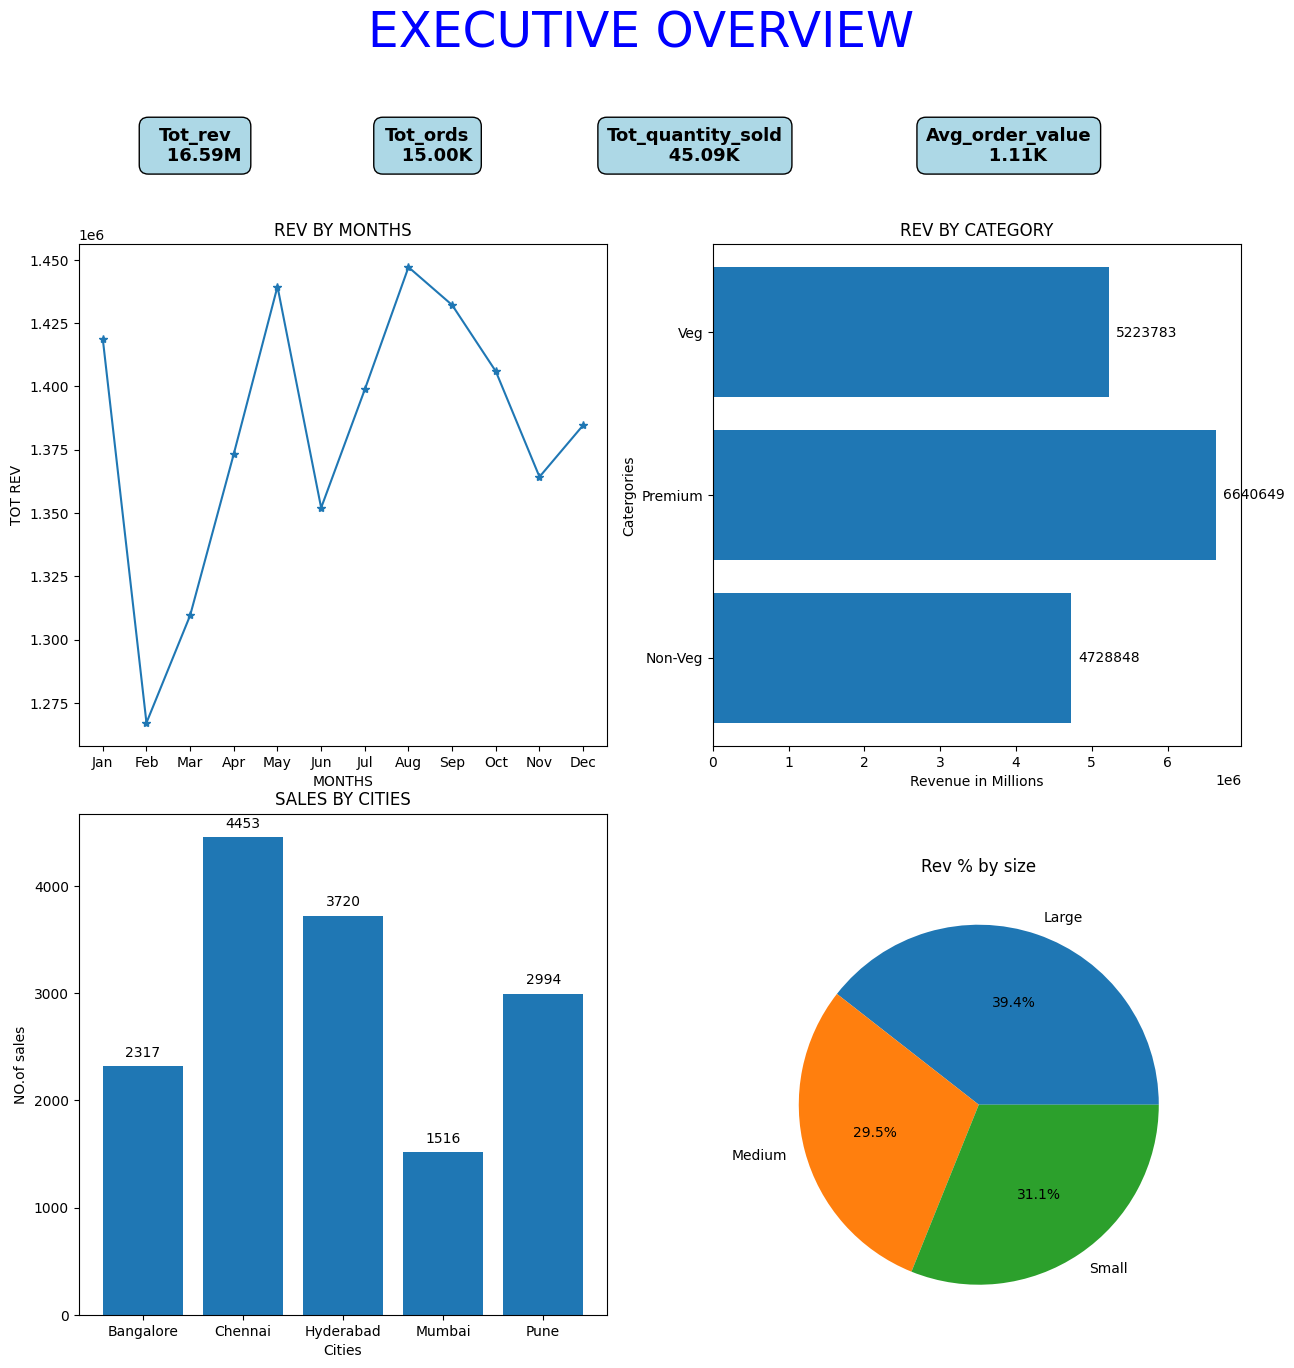

In [ ]:
#Creating the dashboard for the Executive overview

#creating canvos 
figu=plt.figure(figsize=(15,15))
figu.suptitle("EXECUTIVE OVERVIEW",color="blue",size=35)

#Dividing the canvos into grides 
gride=GridSpec(3,2,figure=figu,height_ratios=[0.1,3,3])

#assining the 1 row as a kpi's section 
kpi=plt.subplot(gride[0,:])
kpi.axis("off")

kpi.text(0.10,0.92,f"Tot_rev\n   {smart_format(Tot_rev)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.30,0.92,f"Tot_ords\n   {smart_format(Tot_ords)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.53,0.92,f"Tot_quantity_sold\n   {smart_format(Tot_quantity_sold)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.80,0.92,f"Avg_order_value\n   {smart_format(Avg_order_value)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

#assining the remaining the row and columns to the charts
aix1=figu.add_subplot(gride[1,0])
aix2=figu.add_subplot(gride[1,1])
aix3=figu.add_subplot(gride[2,0])
aix4=figu.add_subplot(gride[2,1])

#line plot of the revenue
aix1.plot(month_dict["month_names"],month_dict["Tot_rev"],marker="*")
aix1.set_title("REV BY MONTHS")
aix1.set_xlabel("MONTHS")
aix1.set_ylabel("TOT REV")

#bar chart of category by the rev
bar_chart=aix2.barh(rev_category['Category'],rev_category['Tot_rev'])
aix2.set_title("REV BY CATEGORY")
aix2.set_xlabel("Revenue in Millions")
aix2.set_ylabel("Catergories")
aix2.bar_label(bar_chart,fmt='%.2f',padding=5)

#bar chart city by sales
bar_chart1=aix3.bar(sales_cities['Store_City'],sales_cities['Order_ID'])
aix3.set_title("SALES BY CITIES")
aix3.set_xlabel("Cities")
aix3.set_ylabel("NO.of sales")
aix3.bar_label(bar_chart1,fmt="%.2f",padding=5)

#pie chart for size of pizza rev
aix4.pie(contribution_of_rev_size['Tot_rev'], labels=contribution_of_rev_size['Size'],autopct="%1.1f%%")
                # autopct shows the % value on each slice automatically
aix4.set_title("Rev % by size")
aix4.set_position([0.5,0.1,0.45,0.30])

plt.show

#phase two analysis strat from the here ---- > Sales analysis dash board 

In [97]:
#ADD-IN's into the dataframe
#Here we replacing the "Operating (OPEX)" with OPEX in the Expense_Category column
dim_expences['Expense_Category']=dim_expences['Expense_Category'].replace({"Operating (OPEX)":"OPEX"})

#Adding a days name column to the fact sales table
fact_sales["weekdays"]=fact_sales['Order_Date'].dt.strftime('%a') 

#Adding a hours column from extracting the hour in Order time
fact_sales['Hours']=pd.to_datetime(fact_sales['Order_Time'],format='%H:%M').dt.hour

In [98]:
# KPI'S section 
Tot_gross_pf=sum(fact_sales['Gross_profit'])
Tot_netPf=Tot_gross_pf-dim_expences['Amount'].sum()
#some of the kpi's were directly added into the canvos
max_ord_val_date=fact_sales.groupby('Order_Date')["Tot_rev"].sum().sort_values(ascending=False).reset_index()



In [99]:
#Measurements for chart's 
# Groupin the weekdays and also sorting them in week order 
rev_overweek=fact_sales.groupby('weekdays').agg({'Tot_rev':'sum','Gross_profit':'sum'}).reset_index()

dfweeknames={'Sun':1,'Mon':2,'Thu':3,'Wed':4,'Tue':5,'Fri':6,'Sat':7}
rev_overweek["weekord"]=rev_overweek['weekdays'].map(dfweeknames)
rev_overweek=rev_overweek.sort_values('weekord')
rev_overweek=rev_overweek.set_index('weekdays')

#Grouping the hours for highest rev in buiness hours
rev_hours=fact_sales.groupby('Hours')['Tot_rev'].sum().reset_index()

#classificationof weekdaya and weekend day's revenue 
rev_weekdays=rev_overweek.loc[['Fri','Mon','Thu','Tue','Wed']].reset_index()
rev_weekends=rev_overweek.loc[['Sat','Sun']].reset_index()

rev_overweek=rev_overweek.reset_index()#after fitching weekdays again we setting this as a dataframe 

#sale by payment method analysi
sales_payment=fact_sales.groupby('Payment_Mode')['Order_ID'].count().reset_index()

#sales by the monthly analysis
sales_monthly=fact_sales.groupby('month_names')['Order_ID'].count().reset_index()

month_order = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

sales_monthly["month_no"] = sales_monthly["month_names"].map(month_order)
sales_monthly= sales_monthly.sort_values("month_no")#sorint the month for proper ploting 



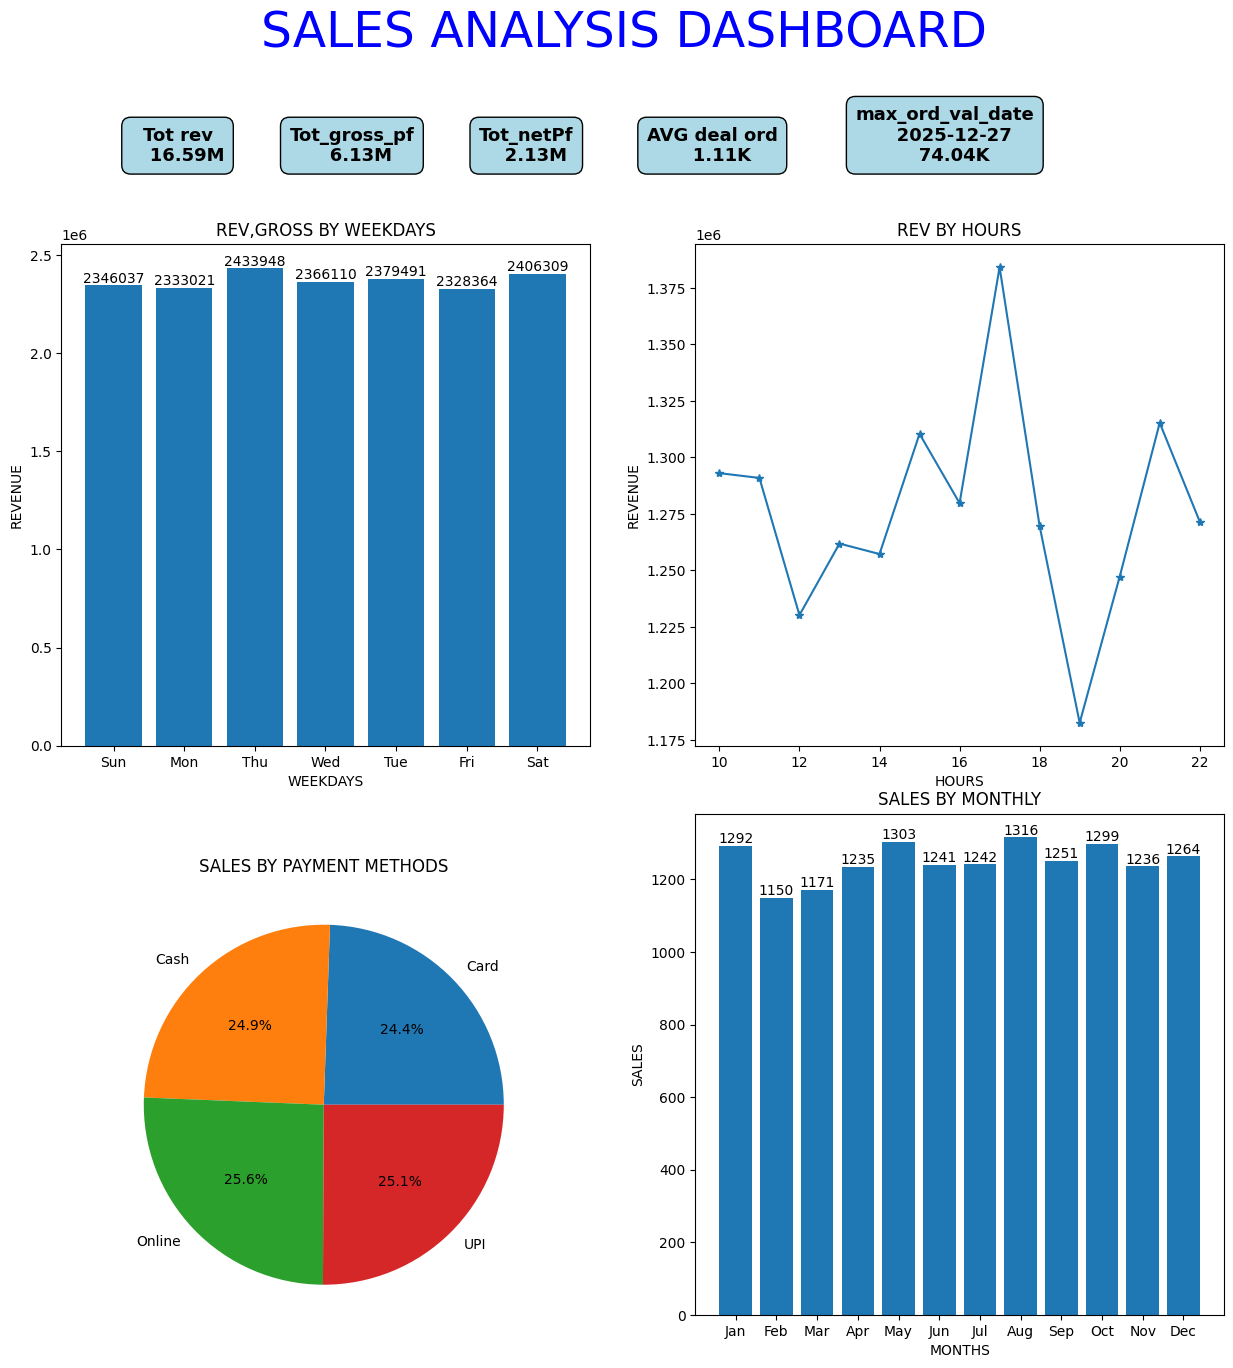

In [ ]:
#Charts
#creating the fingure canvos
figu=plt.figure(figsize=(15,15))
figu.suptitle("SALES ANALYSIS DASHBOARD",color="blue",size=35)

#creating grides
gride=GridSpec(3,2,figure=figu,height_ratios=[0.1,3,3])

#assining the gride 1 row to the canvos
kpi=figu.add_subplot(gride[0,:])
kpi.axis('off')
kpi.text(0.10,0.92,f"Tot rev\n   {smart_format(Tot_rev)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.25,0.92,f"Tot_gross_pf\n   {smart_format(sum(fact_sales['Gross_profit']))}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.40,0.92,f"Tot_netPf\n   {smart_format(Tot_gross_pf-dim_expences['Amount'].sum())}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.56,0.92,f"AVG deal ord\n   {smart_format(Avg_order_value)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi.text(0.76,0.92,f"max_ord_val_date\n   {max_ord_val_date.iloc[0,0].date()}\n   {smart_format(max_ord_val_date.iloc[0,1])}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

#assining the remaining the rows for the charts in the canvos
aix1=figu.add_subplot(gride[1,0])
aix2=figu.add_subplot(gride[1,1])
aix3=figu.add_subplot(gride[2,0])
aix4=figu.add_subplot(gride[2,1])

#creating a bar chart for revenue and grossprofit by weekdays 
char1=aix1.bar(rev_overweek['weekdays'],rev_overweek['Tot_rev'])
aix1.set_title("REV,GROSS BY WEEKDAYS")
aix1.set_xlabel("WEEKDAYS")
aix1.set_ylabel("REVENUE")
aix1.bar_label(char1,fmt="%.2f")

#creating line chart for rev by business hours  
aix2.plot(rev_hours['Hours'],rev_hours['Tot_rev'],marker="*")
aix2.set_title("REV BY HOURS")
aix2.set_xlabel("HOURS")
aix2.set_ylabel("REVENUE")
#aix[0,1].plot_label(char2,fmt="%d")

#creating a pie chart for payment methods by the total sales 
aix3.pie(sales_payment['Order_ID'],labels=sales_payment['Payment_Mode'],autopct="%1.1f%%")
aix3.set_title("SALES BY PAYMENT METHODS")
aix3.set_position([0.1, 0.10, 0.40, 0.30])



#creating a bar char for sales by month 
char3=aix4.bar(sales_monthly['month_names'],sales_monthly['Order_ID'])
aix4.set_title("SALES BY MONTHLY")
aix4.set_xlabel("MONTHS")
aix4.set_ylabel("SALES")
aix4.bar_label(char3,fmt="%.2f")


#print(rev_hours)

plt.show()

PHASE 3 analysis of product performances analysis ------>

In [101]:
#Add-in's in fact tables 

#Adding product name into fact sales table
slice_products=dim_products[['Product_ID','Pizza_Name','Spice_Level']]
fact_sales=fact_sales.merge(slice_products,how='inner',on='Product_ID')

#

In [102]:
#Measurements for KPI'

#Active product measure
Active_pro=dim_products[dim_products['Status']=='Active']# dim_products['Status']=="Active"

#Top n pizza's TOT revenue
top_pizza=fact_sales.groupby('Pizza_Name')['Tot_rev'].sum().reset_index()
top_4_pizzas=top_pizza.nlargest(4,'Tot_rev',)

#Top n pizza's quantity
top_pizza_qunt=fact_sales.groupby('Pizza_Name')['Quantity'].sum().reset_index()
top_4_pizza_qunt=top_pizza_qunt.nlargest(4,'Quantity',) 

#buttom product revenue 
buttom_pro_rev=top_pizza.nsmallest(4,'Tot_rev')

#Quantity per pizza type (product_id) selling
qty_per_Piz_type=fact_sales['Quantity'].sum() / dim_products['Product_ID'].count()

#Avg rev per pizza type we getting 
Avg_rev_per_piz_type=fact_sales['Tot_rev'].sum() / dim_products['Product_ID'].count()

#Avg cost for pizza type 
Avg_cst_per_piz =fact_sales['Tot_cost'].sum() /dim_products['Product_ID'].count()

#Avg rev per piz product contribution  %
rev_ctb_per_piz=(Avg_rev_per_piz_type/ fact_sales['Tot_rev'].sum())*100


In [103]:
#Measures for charts 

#creating a barh chart for revenue by product
rev_by_pro=fact_sales.groupby('Product_ID')['Tot_rev'].sum().reset_index().nlargest(10,'Tot_rev')
rev_by_pro=rev_by_pro.reset_index(drop=True)

#create a sales by the category
sales_by_ctgy=fact_sales.groupby('Category').agg({
    'Order_ID':'count',
    'Tot_rev':'sum'
}).reset_index(drop=False)

#create measure for charts of  rev and sales by product status 
status_by_rev_sales=fact_sales.groupby('Status').agg({
    'Order_ID':'count',
    'Tot_rev':'sum'
}).reset_index(drop=False)

#create measure for sales by the spice level
Avg_piz_pre_time=dim_products.groupby('Pizza_Name').agg({'Preparation_Time_Min':'mean'}).reset_index(drop=False)

[Text(0, 0, '14.27'),
 Text(0, 0, '13.79'),
 Text(0, 0, '14.00'),
 Text(0, 0, '12.67'),
 Text(0, 0, '13.83'),
 Text(0, 0, '14.56'),
 Text(0, 0, '14.14'),
 Text(0, 0, '13.11')]

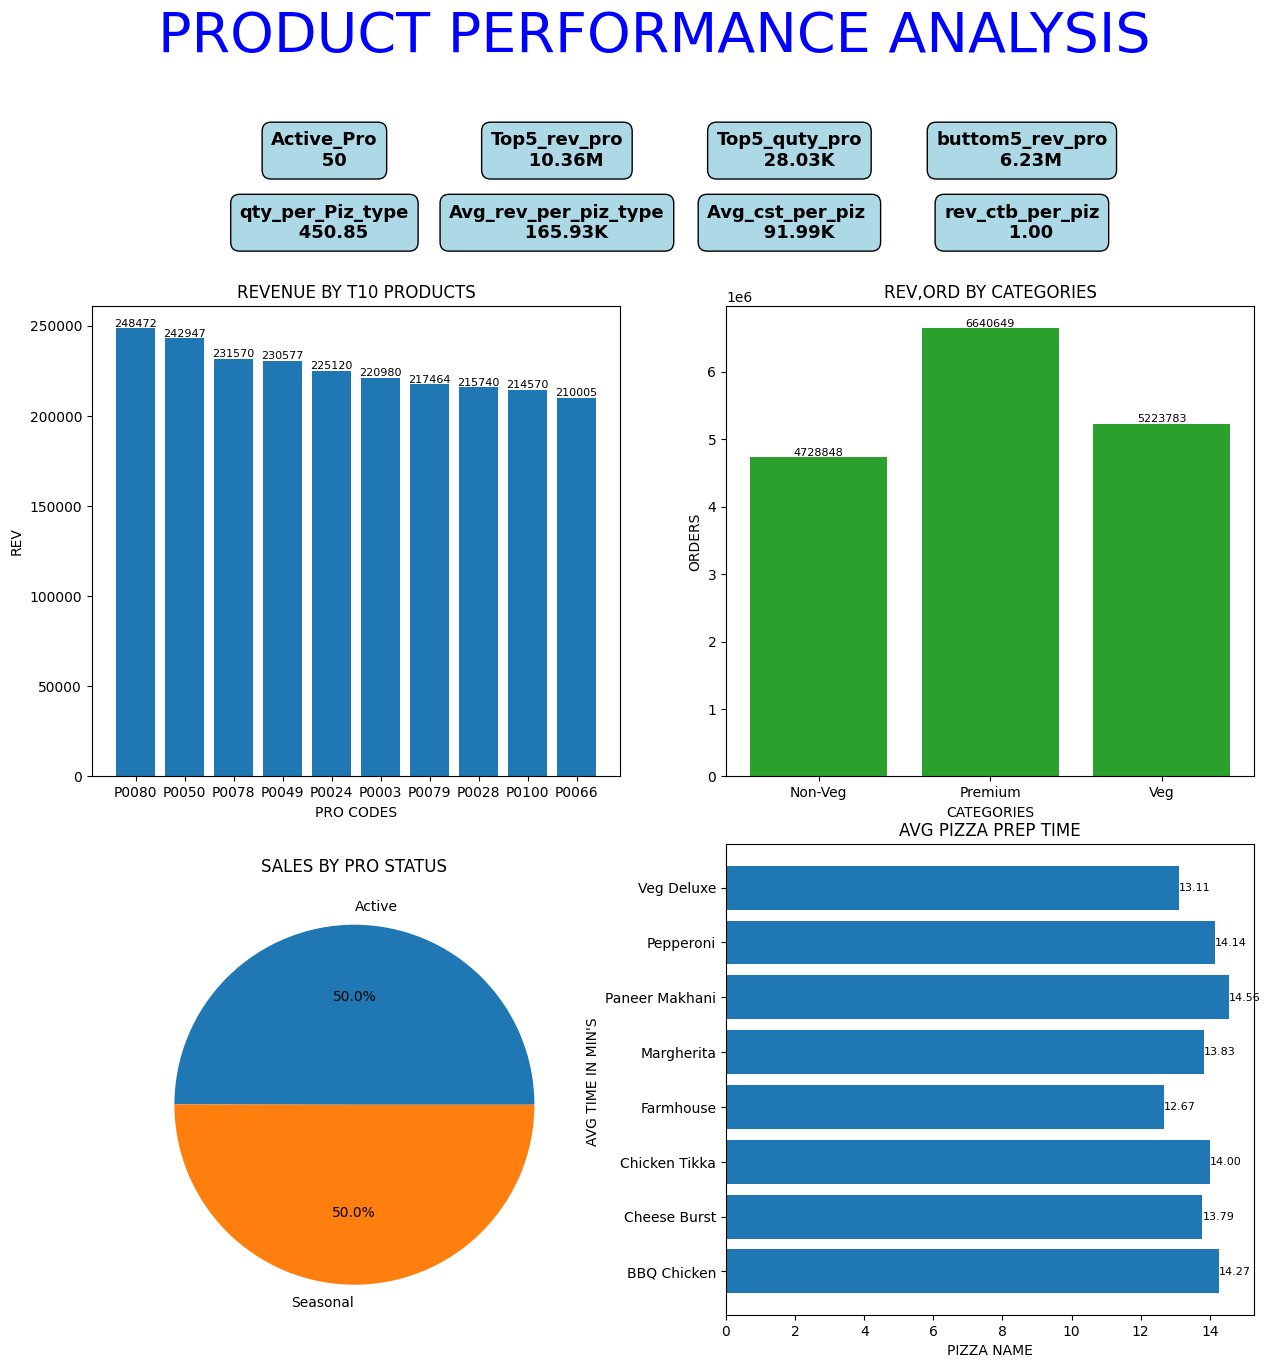

In [ ]:
#Creating the canvos
figu=plt.figure(figsize=(15,15))
figu.suptitle("PRODUCT PERFORMANCE ANALYSIS",size=40,color="blue")

#creating the grid view by Gridspec
gide=GridSpec(3,2,figure=figu,height_ratios=[0.5,3,3])

#assining the 1 row for KPI s
kpi_aix=figu.add_subplot(gide[0,:])
kpi_aix.axis("off")

kpi_aix.text(0.20,0.92,f"Active_Pro\n   {Active_pro["Product_ID"].count()}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.40,0.92,f"Top5_rev_pro\n   {smart_format(top_4_pizzas["Tot_rev"].sum())}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.60,0.92,f"Top5_quty_pro\n   {smart_format(top_4_pizza_qunt["Quantity"].sum())}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.80,0.92,f"buttom5_rev_pro\n   {smart_format(buttom_pro_rev["Tot_rev"].sum())}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.20,0,f"qty_per_Piz_type\n   {qty_per_Piz_type}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.40,0,f"Avg_rev_per_piz_type\n   {smart_format(Avg_rev_per_piz_type)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.60,0,f"Avg_cst_per_piz \n   {smart_format(Avg_cst_per_piz)}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

kpi_aix.text(0.80,0,f"rev_ctb_per_piz\n   {rev_ctb_per_piz:.2f}", ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))



#assining the remaining two row for 2 charts
aix1=figu.add_subplot(gide[1,0])
aix2=figu.add_subplot(gide[1,1])
aix3=figu.add_subplot(gide[2,0])
aix4=figu.add_subplot(gide[2,1])

#creating char for rev by products
char1=aix1.bar(rev_by_pro['Product_ID'],rev_by_pro['Tot_rev'])
aix1.set_title("REVENUE BY T10 PRODUCTS",)
aix1.set_xlabel("PRO CODES")
aix1.set_ylabel("REV")
aix1.bar_label(char1,fmt="%.2f",size=8)

#creating chart for rev by categories
char2=aix2.bar(sales_by_ctgy['Category'],sales_by_ctgy['Order_ID'])
aix2.bar(sales_by_ctgy['Category'],sales_by_ctgy['Tot_rev'])
aix2.set_title("REV,ORD BY CATEGORIES",)
aix2.set_xlabel("CATEGORIES")
aix2.set_ylabel("ORDERS")
aix2.bar_label(aix2.bar(sales_by_ctgy['Category'],sales_by_ctgy['Tot_rev']),fmt="%.2f",size=8)
plt.show

#creating the pie chart for product status analysis
aix3.pie(status_by_rev_sales['Order_ID'] ,labels=status_by_rev_sales['Status'],autopct="%1.1f%%")
aix3.set_title("SALES BY PRO STATUS")
aix3.set_position([0.1, 0.10, 0.40, 0.30])

#creating the barh for sales by the spice level in the pizza
char3=aix4.barh(Avg_piz_pre_time['Pizza_Name'],Avg_piz_pre_time['Preparation_Time_Min'])
aix4.set_title("AVG PIZZA PREP TIME",)
aix4.set_xlabel("PIZZA NAME")
aix4.set_ylabel("AVG TIME IN MIN'S ")
aix4.bar_label(char3,fmt="%.2f",size=8)


Phase 4 customer analysis report / dashboard 

In [ ]:
#ADD-IN's in to the fact_slaes tabels
#addd for related analysis of customer buying behaveiour 
slice_cust=dim_customers[['Customer_ID','City','Age','Loyalty_Member','Signup_Channel']]
fact_sales=fact_sales.merge(slice_cust,how="inner",on='Customer_ID')


In [106]:
#create a bucket column for age 
cond=[
    fact_sales['Age']<=10,
    (fact_sales['Age']>10) & (fact_sales['Age']<=18),
    (fact_sales['Age']>18) & (fact_sales['Age']<=35),
    (fact_sales['Age']>35) & (fact_sales['Age']<=60),
    fact_sales['Age']>60
]

choice=[
    'kids',
    'miners',
    'adults',
    'middle_age',
    'old'
]
fact_sales["Age_bucket"]=np.select(cond,choice)


In [107]:
#Measurements for the KPI'S

#measure for repetation check
repeated_cust=fact_sales.groupby('Customer_ID')['Order_ID'].count().reset_index()
repeated_cust["Cust_type"]=np.where(repeated_cust['Order_ID']>2,"repeated","New commer")
repeated_cust=repeated_cust.groupby('Cust_type').agg({'Customer_ID':'count'}).reset_index()


#Avg customer spending over the year
Avg_cust_spending=Tot_rev/dim_customers['Customer_ID'].count()

#Avg orders customers placed
Avg_cust_orders=Tot_ords/dim_customers['Customer_ID'].count()

#calculating avg customer rating 
Avg_cust_rating=fact_sales.groupby('Customer_Rating')['Order_ID'].count().reset_index().nlargest(1,'Order_ID').reset_index(drop=True)

In [108]:
#Measures for charts
#analysis the ages bucket for which age group bying the most
age_bucket=fact_sales.groupby('Age_bucket').agg({
    'Tot_rev':'sum',
    'Order_ID':'count'
}).reset_index()

#where the cities the customers coming from
uni_cust=dim_customers.groupby('City')['Customer_ID'].count().reset_index()
most_cust=fact_sales.groupby('City').agg({'Order_ID':'count','Tot_rev':'sum'}).reset_index()
most_cust=most_cust.merge(uni_cust,how='inner',on='City')

#from which signup channel the customer coming 
singup_cust=fact_sales.groupby('Signup_Channel').agg({'Order_ID':'count'}).reset_index()

#loyality member ship analysis
loyalty_cust=dim_customers.groupby('Loyalty_Member')['Customer_ID'].count().reset_index()

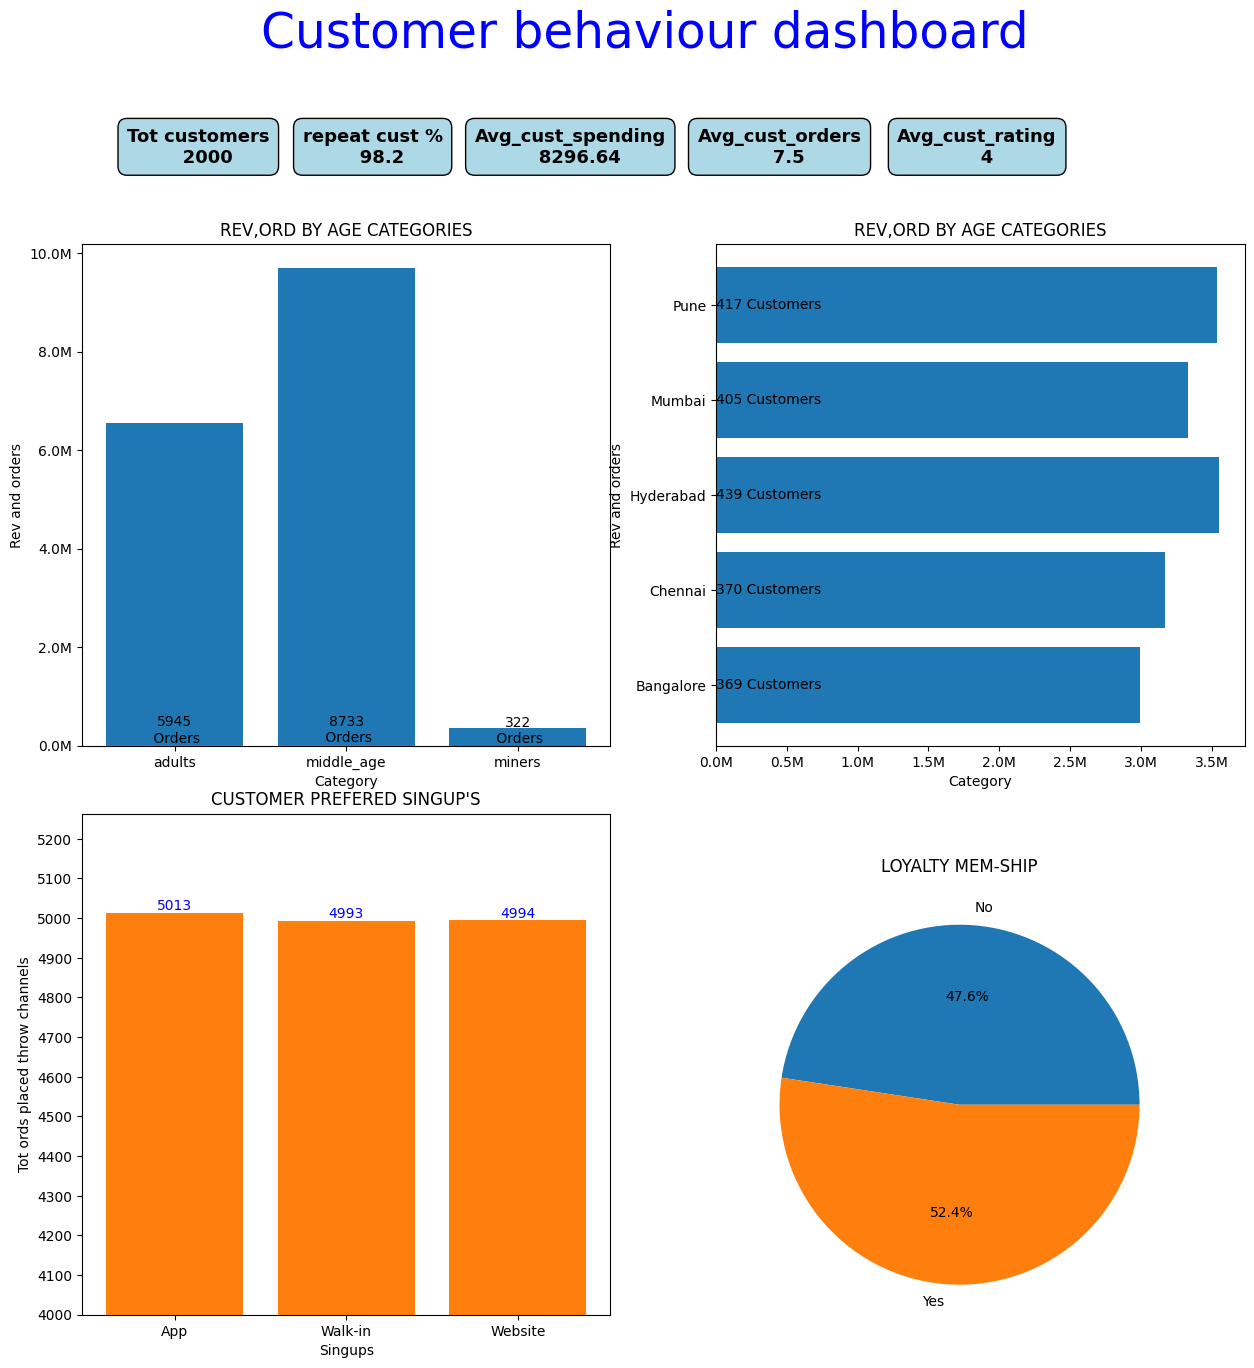

In [ ]:
#dashboard / repport devlopment 
#creating the canvos
ph4_fig=plt.figure(figsize=(15,15))
ph4_fig.suptitle("Customer behaviour dashboard",size=35,color="blue")

#dividing the canvos into the grides
ph4_grids=GridSpec(3,2,height_ratios=[0.1,3,3])

#assigning the first row for kpi's
ph4_kpis=ph4_fig.add_subplot(ph4_grids[0,:])
ph4_kpis.axis('off')

ph4_kpis.text(0.1,0.85,f"Tot customers\n   {dim_customers['Customer_ID'].count()}",ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

ph4_kpis.text(0.25,0.85,f"repeat cust %\n   {(repeated_cust.iloc[1,1]/dim_customers['Customer_ID'].count())*100}",ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

ph4_kpis.text(0.42,0.85,f"Avg_cust_spending\n   {Avg_cust_spending}",ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

ph4_kpis.text(0.60,0.85,f"Avg_cust_orders\n   {Avg_cust_orders}",ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

ph4_kpis.text(0.77,0.85,f"Avg_cust_rating\n   {Avg_cust_rating.iloc[0,0]}",ha='center', 
         fontsize=13, weight='bold',bbox=dict(facecolor='lightblue', boxstyle='round,pad=0.5'))

#assigning the remaing the rows to the aix's
aix1=ph4_fig.add_subplot(ph4_grids[1,0])
aix2=ph4_fig.add_subplot(ph4_grids[1,1])
aix3=ph4_fig.add_subplot(ph4_grids[2,0])
aix4=ph4_fig.add_subplot(ph4_grids[2,1])

#create a bar chart for the age status 
aix1.bar(age_bucket['Age_bucket'],age_bucket['Tot_rev'])
aix1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p:  f'{x/1e6:.1f}M'))
aix1.bar(age_bucket['Age_bucket'],age_bucket['Order_ID'])
aix1.bar_label(aix1.bar(age_bucket['Age_bucket'],age_bucket['Order_ID']),fmt="%d"+"\n Orders")
aix1.set_title('REV,ORD BY AGE CATEGORIES')
aix1.set_xlabel("Category")
aix1.set_ylabel("Rev and orders")
plt.show

#create a bah chart to show the city way customer purchese behave]
aix2.barh(most_cust['City'],most_cust['Tot_rev'])
aix2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p:  f'{x/1e6:.1f}M'))
aix2.barh(most_cust['City'],most_cust['Customer_ID'])
aix2.bar_label(aix2.barh(most_cust['City'],uni_cust['Customer_ID']),fmt="%d"+" Customers",)
aix2.set_title('REV,ORD BY AGE CATEGORIES')
aix2.set_xlabel("Category")
aix2.set_ylabel("Rev and orders")
plt.show

#create a line plot to show the trend over the singup of the customers (how they actually)
aix3.bar(singup_cust['Signup_Channel'],singup_cust['Order_ID'])
aix3.set_title("CUSTOMER PREFERED SINGUP'S")
aix3.set_xlabel("Singups")
aix3.set_ylabel('Tot ords placed throw channels')
aix3.set_ylim(bottom=4000)
aix3.yaxis.set_major_locator(mticker.MultipleLocator(100))
aix3.bar_label(aix3.bar(singup_cust['Signup_Channel'],singup_cust['Order_ID']),fmt="%d",label_type='edge',color="blue")

#creating the pie chart for loyalty status analysis
aix4.pie(loyalty_cust['Customer_ID'] ,labels=loyalty_cust["Loyalty_Member"],autopct="%1.1f%%")
aix4.set_title("LOYALTY MEM-SHIP")
aix4.set_position([0.36, 0.1, 0.7, 0.3])

In [110]:
shapes=fact_sales.shape
pd.set_option("display.max_columns",shapes[1])
fact_sales.head(5)

,Order_ID,Order_Date,Order_Time,Customer_ID,Product_ID,Store_ID,Quantity,Discount_%,Tax_%,Delivery_Charge,Payment_Mode,Order_Type,Delivery_Time_Min,Customer_Rating,Sales_Channel,Coupon_Code,Cost_Price,Selling_Price,Tot_rev,Tot_cost,dic_redict_value,Gross_profit,month_names,Category,Size,Status,Store_City,weekdays,Hours,Pizza_Name,Spice_Level,City,Age,Loyalty_Member,Signup_Channel,Age_bucket
0,O000001,2025-01-24,12:31,C01363,P0017,S0009,2,9,5,21,UPI,Dine-In,51,5,Walk-in,SAVE15,251,351,702,502,659.82,157.82,Jan,Non-Veg,Large,Seasonal,Pune,Fri,12,Paneer Makhani,4,Chennai,55,No,Walk-in,middle_age
1,O000002,2025-12-14,18:47,C01996,P0006,S0013,3,4,5,36,Online,Delivery,17,3,Website,NEW10,113,212,636,339,646.56,307.56,Dec,Premium,Medium,Active,Hyderabad,Sun,18,Farmhouse,1,Mumbai,29,Yes,App,adults
2,O000003,2025-09-25,22:01,C01438,P0044,S0016,1,6,5,47,UPI,Delivery,21,3,Walk-in,SAVE15,258,383,383,258,407.02,149.02,Sep,Non-Veg,Large,Seasonal,Bangalore,Thu,22,Margherita,2,Hyderabad,27,No,Website,adults
3,O000004,2025-05-31,21:59,C00701,P0005,S0010,3,6,5,45,Cash,Dine-In,59,3,Website,NONE,178,270,810,534,806.40,272.40,May,Veg,Medium,Active,Bangalore,Sat,21,Veg Deluxe,1,Chennai,27,No,Website,adults
4,O000005,2025-12-02,16:10,C00776,P0026,S0008,3,20,5,17,UPI,Delivery,28,3,Walk-in,SAVE15,273,367,1101,819,897.80,78.80,Dec,Premium,Large,Seasonal,Pune,Tue,16,BBQ Chicken,1,Hyderabad,20,Yes,App,adults
